<a href="https://colab.research.google.com/github/fedhere/DSPS_FBianco/blob/master/HW10/DSPS2021_CONVaenc_faces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

author FBB for EthicsAI2021

# Autoencoder notebook 
create superresolution portraits from low resolution black and white images:
- load a patch of images and lower the resolution
- build an autoencoder with a bottleneck layer much smaller thn the number of pixels in an image
- pass the lower resolution images as imput and the higher resolution images as output
- ask the encoder to predict high resolution images from low resolution ones
- test it on a headshot of yourself

In [ ]:
from google.colab import drive

drive.mount("/content/gdrive")


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
from keras.models import Sequential
from keras.layers import Dense#, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from keras import backend as K


In [ ]:
import glob
import h5py
from PIL import Image
import numpy as np
import pylab as pl
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
cd /content/gdrive/Shareddrives/


/content/gdrive/Shareddrives


In [ ]:
ls

 AILE/                     DPAcolloquia/  'P&T'/
'AILE (1)'/                DSPS2021/       PUS2020/
 APSInnovationFund20201/   FASTlab/        pyboot/
 bogcl/                    FFTPCA/         RubinOLSSTPixelLevelTF/
 ChimeDE/                  MLTSA2020/     'UD COVID19 Hackathon'/
 classes/                  NSFDSC2021/
'DPA CDEI'/                phys207/


In [ ]:
cd  DSPS2021/

/content/gdrive/Shareddrives/DSPS2021


# 1A load head shots from known training data - skip to 1B to load images already read in
The first time you will need to dowbload faces95.zip. Uncomment the 2 lines of code below

In [ ]:
# this link no longer works due to the backlash of the algorithm that whitened Obama
# but I saved the data in our shared drive
#!wget http://www.cl.cam.ac.uk/Research/DTG/attarchive/pub/data/att_faces.zip


In [ ]:
#!unzip faces95.zip

In [ ]:
!ls data/faces95/*jpg

data/faces95/adhast.10.jpg  data/faces95/llambr.10.jpg
data/faces95/adhast.11.jpg  data/faces95/llambr.11.jpg
data/faces95/adhast.12.jpg  data/faces95/llambr.12.jpg
data/faces95/adhast.13.jpg  data/faces95/llambr.13.jpg
data/faces95/adhast.14.jpg  data/faces95/llambr.14.jpg
data/faces95/adhast.15.jpg  data/faces95/llambr.15.jpg
data/faces95/adhast.16.jpg  data/faces95/llambr.16.jpg
data/faces95/adhast.17.jpg  data/faces95/llambr.17.jpg
data/faces95/adhast.18.jpg  data/faces95/llambr.18.jpg
data/faces95/adhast.19.jpg  data/faces95/llambr.19.jpg
data/faces95/adhast.1.jpg   data/faces95/llambr.1.jpg
data/faces95/adhast.20.jpg  data/faces95/llambr.20.jpg
data/faces95/adhast.2.jpg   data/faces95/llambr.2.jpg
data/faces95/adhast.3.jpg   data/faces95/llambr.3.jpg
data/faces95/adhast.4.jpg   data/faces95/llambr.4.jpg
data/faces95/adhast.5.jpg   data/faces95/llambr.5.jpg
data/faces95/adhast.6.jpg   data/faces95/llambr.6.jpg
data/faces95/adhast.7.jpg   data/faces95/llambr.7.jpg
data/faces95/adha

In [ ]:
flist = glob.glob("data/faces95/*jpg")

In [ ]:
N = len(flist)
N

1440


## read in data

if you save the data in a npy array you can read it in more quickly. After the first time you run this you can comment out the next 2 cells of code and skip to the np.load command

((70, 70, 1), 540)

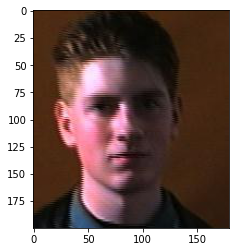

In [ ]:
im = Image.open(flist[40])
np_im = numpy.array(im)[:,:,:3].astype(float) / 255 #normalize the images so that they are 0-1
pl.imshow(np_im)
# I am going to need only a subset of the image: the center part where the head is

np_im[25:165:2,25:165:2,:1].shape, np.prod(np_im.shape[1:])

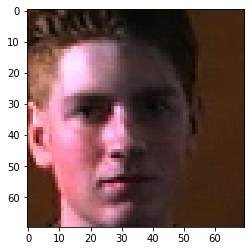

In [ ]:
pl.imshow(np_im[25:165:2,25:165:2])

<font color='red'>you can skip this and go  straight to loading the images</font>

In [ ]:
#skip and read the saved version if you have saved it (after the first time you run this cell)
# I also use a single color channel (black and white)
imgs = np.zeros((N, 70, 70, 1))
for i,f in enumerate(flist):
  if not i%50: print(i)
  im = Image.open(flist[i])
  np_im = numpy.array(im)[:,:,:3].astype(float) / 255 
  # here I collect the certain portion of each image 
  # from pixel 25 to 165 on the x and y axis (25:165)
  # and subsampling by a factor 2 (25:165:2)
  # and I am only choosing 1 color layer: [...,:1]: the R in RGB layers
  imgs[i] = numpy.array(im)[25:165:2,25:165:2,:1].astype(float) / 255 
#uncomment this to save another array of images - I saved the original one as data/faces.npy
#np.save("data/faces_saved.npy", imgs)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400


# 1B you can read the images below if you have saved them earlier

In [ ]:
imgs = np.load("data/faces.npy")
imgs.shape

(1440, 70, 70, 1)

## 2 lower the resolution#
keep printing the shape of the images as you go along:

make a copy of the original before you lower the res 

- sample the image every other pixel to get a 35x35 image and only (the shape of the image set should be 1440,35,35,1
- create a 75/25 train/test set with the command 
          train_test_split(input, target, test_size = .25, random_state=1) 
          What are the input and output data??
- the data will be fed as a single row of pixels, so for example each imput image should be reshaped so that  the image array so that eachimage is 35*35 long: reshape the 4 arrays: input training, output training, input test and output test so that they are they are the appropriate shape (each should be Nimages x Npixel)

## Meet me at the enf of that to create the autoencoder.

In [ ]:
#imgs orig is the full resolution image
imgs_orig = imgs.copy()

In [ ]:
# lower the resolution
# imgs_lr = imgs[:,::2,::2]
# slightly better than the line of code above
imgs_lr = imgs.reshape(imgs.shape[0], int(imgs.shape[1]/2), 2, 
                        int(imgs.shape[2]/2), 2
                       ).mean(axis=-1).mean(axis=2)
imgs_lr.shape

(1440, 35, 35)

In [ ]:
#this is the number of pixels in the image
np.prod(imgs_lr[1].shape), np.prod(imgs[1].shape), 

(1225, 4900)

#### generate a train and test set
If I want to predict the image at the same resolution I will pass the same input as the target variable. Otherwise the target variable will be a full resolution image set and the low input the lower resolution one

In [ ]:
from sklearn.model_selection import train_test_split
X_tr,  X_te, y_tr, y_te = train_test_split(imgs_lr, imgs_orig, 
                                             test_size = .20, random_state=1)
  

In [ ]:
X_tr.shape, X_te.shape, y_tr.shape, y_te.shape

((1152, 35, 35), (288, 35, 35), (1152, 70, 70, 1), (288, 70, 70, 1))

In [ ]:
#each image needs to be unravel into a flat array
X_tr = X_tr.reshape(len(X_tr), X_tr.shape[1], X_tr.shape[2], 1)
X_te = X_te.reshape(len(X_te), X_tr.shape[1], X_tr.shape[2], 1)
y_tr = y_tr.reshape(len(y_tr), y_tr.shape[1], y_tr.shape[2], 1)
y_te = y_te.reshape(len(y_te), y_tr.shape[1], y_tr.shape[2], 1)

In [ ]:
## important: we feed to the NN rows of pixels, not cubes of pixels
X_tr.shape, X_te.shape, y_tr.shape, y_te.shape

((1152, 35, 35, 1), (288, 35, 35, 1), (1152, 70, 70, 1), (288, 70, 70, 1))

## 3 build an autoencoder model

Remember that the autoencoder is an hour clock model: the center is a smallest layer

for example your NN layers could be 

324 (input size) -> 256 -> 128 -> 56 -> 128 -> 256 -> 1225 (output size)

In [ ]:
# this model is 324 (input size) -> 256 -> 128 128 -> 256 -> 1225 (output size)

model = Sequential()
model.add(Conv2D(256, kernel_size=[2,2], activation='relu', padding="same",
                 input_shape=(35,35,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128, kernel_size=(3,3), padding="same", activation='relu'))
#model.add(MaxPooling2D(pool_size=(3,3), name="bottle_neck"))
model.add(Conv2DTranspose(128, (3, 3), strides=2, padding="same", activation="relu"))
#model.add(Conv2DTranspose(128, kernel_size=(2,2), strides=1, activation='relu'))
#model.add(Conv2DTranspose(128, kernel_size=(2,2), strides=1, activation='relu'))

model.add(Conv2DTranspose(128, kernel_size=(3,3), strides=1, padding="same", activation='relu'))
model.add(Conv2DTranspose(128, kernel_size=(2,2), strides=1, activation='relu'))


model.add(Conv2DTranspose(1, kernel_size=(2,2), strides=2, padding="same", activation='relu'))
#model.add(Conv2D(256, kernel_size=[2,2], activation='relu'))
#model.add(UpSampling2D(size=(2,2)))
#model.add(Conv2D(1024, kernel_size=[2,2], activation='relu'))
#model.add(UpSampling2D(size=(2,2)))
#model.add(Conv2D(1024, kernel_size=[3,3], activation='relu'))
#model.add(UpSampling2D(size=(2,2)))
#model.add(Conv2D(1024, kernel_size=[6,6], activation='relu'))
#model.add(UpSampling2D(size=(2,2)))
#model.add(Dense((1), activation='sigmoid'))
model.compile(optimizer='adamax', loss='mse',
              metrics=['mae', 'acc'])# optimizer="adadelta", loss="kullback_leibler_divergence")


In [ ]:
model.build()
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 35, 35, 256)       1280      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 17, 17, 256)      0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 17, 17, 128)       295040    
                                                                 
 conv2d_transpose_22 (Conv2D  (None, 34, 34, 128)      147584    
 Transpose)                                                      
                                                                 
 conv2d_transpose_23 (Conv2D  (None, 34, 34, 128)      147584    
 Transpose)                                                      
                                                      

## 4 A train model OR you can skip and load the pretrained I saved for you! (as long as you did not change the architecture
or to read in the saved model skip this cell, or skip the whole section and read a model from http://fbb.space/mltsa/imgreconstruct_10000.h5

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint
callback = EarlyStopping(monitor='val_loss',
                         patience=3,
                         min_delta=0.000001)

model_checkpoint_callback = ModelCheckpoint(
    filepath="checkpointConv.",
    save_weights_only=True,
    monitor='val_mae',
    mode='min',
    save_best_only=True)



In [ ]:
# you can skip this and load the saved model
history = model.fit( X_tr, y_tr, epochs=300, 
                    validation_data=[X_te, y_te],
                    batch_size= 16, verbose=1,
                    callbacks=[callback, model_checkpoint_callback])


Epoch 1/300
72/72 [==============================] - 65s 906ms/step - loss: 8.1461e-04 - mae: 0.0162 - acc: 0.0046 - val_loss: 8.1595e-04 - val_mae: 0.0163 - val_acc: 0.0043
Epoch 2/300
72/72 [==============================] - 65s 904ms/step - loss: 8.0736e-04 - mae: 0.0161 - acc: 0.0046 - val_loss: 8.0870e-04 - val_mae: 0.0163 - val_acc: 0.0043
Epoch 3/300
72/72 [==============================] - 65s 901ms/step - loss: 7.9851e-04 - mae: 0.0160 - acc: 0.0046 - val_loss: 7.9248e-04 - val_mae: 0.0160 - val_acc: 0.0043
Epoch 4/300
72/72 [==============================] - 65s 905ms/step - loss: 7.9593e-04 - mae: 0.0160 - acc: 0.0046 - val_loss: 7.8782e-04 - val_mae: 0.0160 - val_acc: 0.0043
Epoch 5/300
72/72 [==============================] - 65s 900ms/step - loss: 7.9254e-04 - mae: 0.0160 - acc: 0.0046 - val_loss: 8.2080e-04 - val_mae: 0.0169 - val_acc: 0.0043
Epoch 6/300
72/72 [==============================] - 65s 903ms/step - loss: 8.0988e-04 - mae: 0.0164 - acc: 0.0046 - val_loss: 7.6

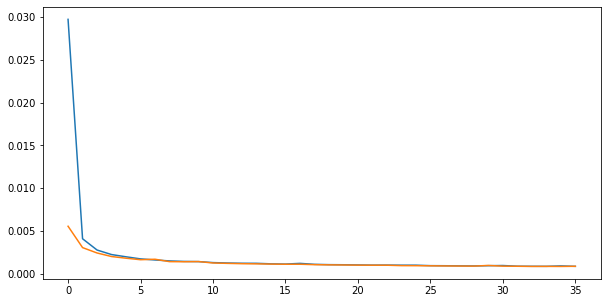

In [ ]:
pl.plot(history.history["loss"])
pl.plot(history.history["val_loss"])

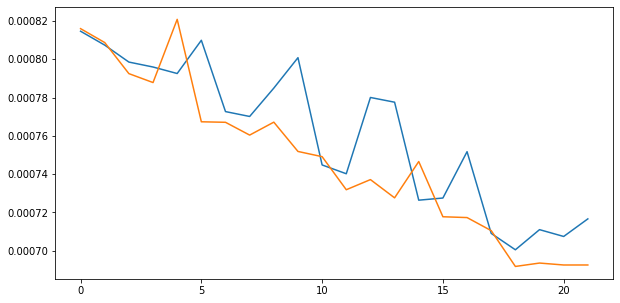

In [ ]:
pl.plot(history.history["loss"])
pl.plot(history.history["val_loss"])

In [ ]:
model.save("data/imgreconstructConv_10000.h5")

In [ ]:
# READ IN THE SAVED MODEL
#!wget http://fbb.space/mltsa/imgreconstruct_10000.h5
model.load_weights("data/imgreconstructConv_10000.h5")

## predict

In [ ]:
outim = model.predict(X_te[:10])
outim

array([[[[0.20634037],
         [0.20370165],
         [0.20066074],
         ...,
         [0.10918753],
         [0.11793684],
         [0.12207428]],

        [[0.20446923],
         [0.2020193 ],
         [0.1991728 ],
         ...,
         [0.08387244],
         [0.10979996],
         [0.11589984]],

        [[0.21068496],
         [0.20501742],
         [0.20022959],
         ...,
         [0.06668711],
         [0.10033987],
         [0.11499388]],

        ...,

        [[0.1615473 ],
         [0.15714699],
         [0.15554193],
         ...,
         [0.09781061],
         [0.0878496 ],
         [0.09552047]],

        [[0.15731698],
         [0.155981  ],
         [0.16036117],
         ...,
         [0.07486521],
         [0.07957692],
         [0.09472702]],

        [[0.15664709],
         [0.1579904 ],
         [0.16489539],
         ...,
         [0.05862583],
         [0.07818911],
         [0.09303886]]],


       [[[0.28873855],
         [0.2907704 ],
         [0.29

In [ ]:
def compareinout(i, outim, X_tr):
  '''function to plot the input, the prediction and the target in 3 columns
  plots the ith training datum'''
  fig = pl.figure(figsize(10,5))
  ax = fig.add_subplot(131) 
  #ax.imshow(X_te[i].reshape(imgs_lr[i].shape[:2]) , cmap="bone")
  ax.imshow(X_te[i].reshape(35,35), cmap="bone")
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
  ax = fig.add_subplot(132) 
  #ax.imshow(outim[i].reshape(imgs_orig[i].shape[:2]) , cmap="bone")
  ax.imshow(outim[i].reshape(70,70), cmap="bone")
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
  ax = fig.add_subplot(133) 
  #ax.imshow(y_te[i].reshape(imgs_orig[i].shape[:2]) , cmap="bone")
  ax.imshow(y_te[i].reshape(70,70), cmap="bone")
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)


1 :	input		      prediction		  target


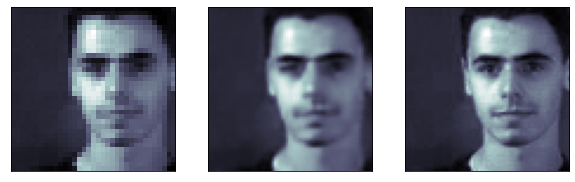

2 :	input		      prediction		  target


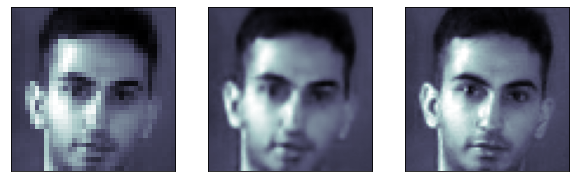

3 :	input		      prediction		  target


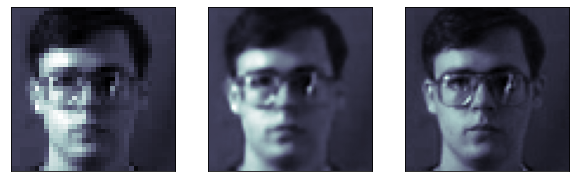

4 :	input		      prediction		  target


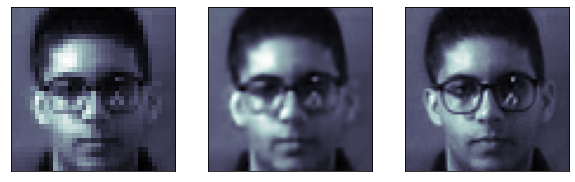

5 :	input		      prediction		  target


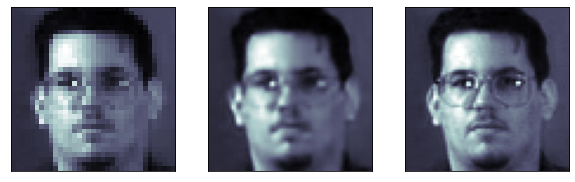

6 :	input		      prediction		  target


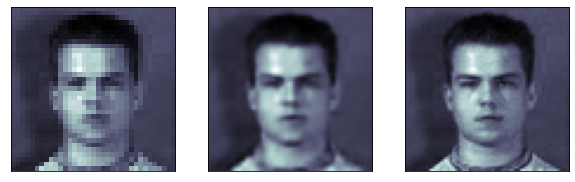

7 :	input		      prediction		  target


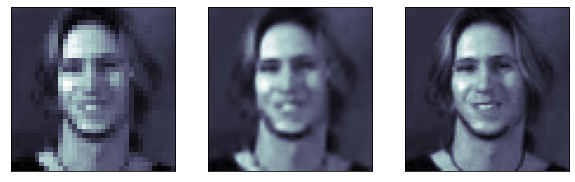

8 :	input		      prediction		  target


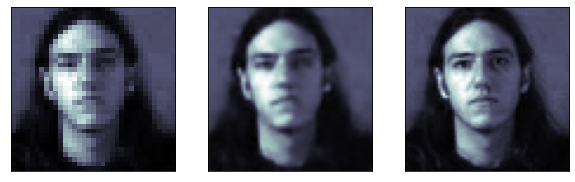

9 :	input		      prediction		  target


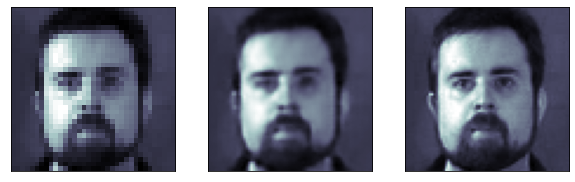

10 :	input		      prediction		  target


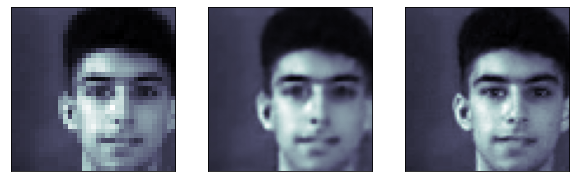

In [ ]:
np.random.seed(123)
# pick a few random test images
for i in range(10):
  j = np.random.randint(0, len(X_te))
  print(i + 1, ":\tinput\t\t      prediction\t\t  target")
  compareinout(i, outim, X_te[:10])
  pl.show()

What do you think? some are pretty good right?! e.g. 1, 4, 6, 7, 8

Some are really bad. 9... why?

# test the model on your own image
 depending on the initial size you will have to downsample the image, and extract a single color layer

In [ ]:
imme = Image.open("data/testimg.png")

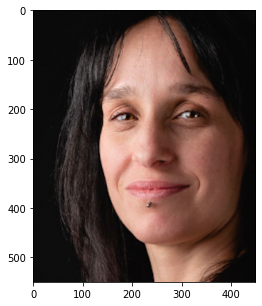

In [ ]:

np_im = numpy.array(imme)[:,:,:3].astype(float) / 255
pl.figure()
pl.imshow(np_im[50:600,250:700,:] )
np_im[100:625,250:775,:].shape, np.prod(np_im.shape[1:]);


low resolution version
subsampling by 15

In [ ]:
np_im_me = np_im[100:625,250:775,:][::15,::15,1]
np_im_me.shape

(35, 35)

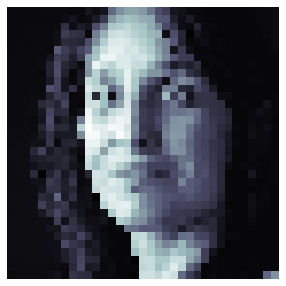

In [ ]:

pl.imshow(np_im_me, cmap="bone")
pl.axis('off');

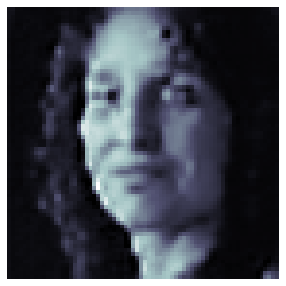

In [ ]:
pl.imshow(model.predict(np.array([np_im_me.reshape(35,35,1)])).reshape(70,70), 
          cmap="bone")
pl.axis('off');

# ... not good at all :-( why??